# Snapshot comparison

This notebook compares a **candidate** BCSD run against the canonical global
**snapshot** baseline, leaf by leaf, under the per-variable tolerances. The candidate
and the snapshot are separate stores read on their own icechunk branches
(`candidate_branch`, `snapshot_branch`) — these need not match. The South Africa
candidate is produced over a small **halo** beyond the region of interest, because
BCSD's regrid and spatial disaggregation have edge effects at the domain boundary;
`roi_bounds` trims both runs back to the region of interest (`mode = "southafrica"`) so
only interior cells — which had full neighborhoods in both runs — are compared. For the
full change-detected path (`mode = "global"`) a global candidate is compared against the
global snapshot as-is. See `docs/explanation/snapshot-testing.md` for why this check
exists and how the merge decision is made.

It is parameterized with [papermill](https://papermill.readthedocs.io/): the first code
cell is tagged `parameters`, so `snapshot_uri`, `snapshot_branch`, `candidate_uri`,
`candidate_branch`, `mode`, `roi_bounds`, `scenarios`, `variables`, and `time_index` can
be overridden at execution time.

In [1]:
from srm.snapshot.baselines import CESM2_WACCM_GLOBAL

snapshot_uri = CESM2_WACCM_GLOBAL.uri
snapshot_branch = CESM2_WACCM_GLOBAL.branch
# The candidate is a separate store on its own branch; it need not match the snapshot.
# Set candidate_branch to whatever branch your SA run wrote to (the installed package
# version by default, unless you set BCSD_BRANCH when producing it).
candidate_branch = "v0.8.0.post1"
# "southafrica" = cheap check (subset the global snapshot to the candidate's extent);
# "global" = full change-detected path (candidate already global, no subset).
mode = "southafrica"
# The SA candidate is produced over a ~3 deg halo. roi_bounds trims both runs back to
# the region of interest before comparing, excluding BCSD edge effects at the halo
# boundary. [lat_min, lat_max, lon_min, lon_max]; set to None to compare the full extent.
candidate_uri = (
    "s3://carbonplan-scratch/srm/output/qa/CESM2-WACCM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk"
)
roi_bounds = [-35, -22, 16, 33]
scenarios = None  # None = all groups; or e.g. ["g6_1p5k"]
variables = None  # None = all; or e.g. ["tas", "pr"]
time_index = 0

In [2]:
import xarray as xr

from srm.snapshot.compare import _iter_leaf_datasets
from srm.snapshot.runs import _compare_datatrees
from srm.validation import _open_output_datatree


def _crop_to_roi(ds, bounds):
    """Select the cells of ``ds`` inside [lat_min, lat_max, lon_min, lon_max]."""
    lat_min, lat_max, lon_min, lon_max = bounds
    idx = {}
    if "lat" in ds.coords:
        idx["lat"] = ds.lat[(ds.lat >= lat_min) & (ds.lat <= lat_max)]
    if "lon" in ds.coords:
        idx["lon"] = ds.lon[(ds.lon >= lon_min) & (ds.lon <= lon_max)]
    return ds.sel(idx) if idx else ds


candidate_tree = _open_output_datatree(candidate_uri, branch=candidate_branch)
snapshot_tree = _open_output_datatree(snapshot_uri, branch=snapshot_branch)

if mode == "southafrica":
    # Trim the candidate to the region of interest (drop the halo), then subset the
    # global snapshot to those exact cells. Plain .sel: raises if a coordinate is
    # missing, so grid drift fails loudly (no coordinate resetting).
    cand_leaves = {
        path: (_crop_to_roi(ds, roi_bounds) if roi_bounds else ds)
        for path, ds in _iter_leaf_datasets(candidate_tree)
    }
    snap_subset = {}
    for path, snap_ds in _iter_leaf_datasets(snapshot_tree):
        c = cand_leaves.get(path)
        if c is not None:
            idx = {d: c[d] for d in ("lat", "lon") if d in c.coords and d in snap_ds.coords}
            if idx:
                snap_ds = snap_ds.sel(idx)
        snap_subset["/" + path if path else "/"] = snap_ds
    candidate_tree = xr.DataTree.from_dict(
        {"/" + p if p else "/": ds for p, ds in cand_leaves.items()}
    )
    snapshot_tree = xr.DataTree.from_dict(snap_subset)

report = _compare_datatrees(candidate_tree, snapshot_tree, scenarios=scenarios, variables=variables)

print("OVERALL:", "PASS" if report.within_tolerance else "FAIL")
for leaf in sorted(report.leaves, key=lambda lf: lf.path):
    flag = "ok " if leaf.within_tol else "OUT"
    print(
        f"[{flag}] {leaf.path:44s} max_abs={leaf.max_abs_diff:.3e} frac>tol={leaf.frac_over_tol:.3e}"
    )

OVERALL: FAIL
[OUT] debiased_coarse/g6_1p5k/dtr/003/dtr          max_abs=1.033e-01 frac>tol=7.543e-06
[OUT] debiased_coarse/g6_1p5k/hurs/003/hurs        max_abs=5.591e+00 frac>tol=1.369e-05
[ok ] debiased_coarse/g6_1p5k/pr/003/pr            max_abs=1.746e-10 frac>tol=0.000e+00
[OUT] debiased_coarse/g6_1p5k/rsds/003/rsds        max_abs=1.619e+02 frac>tol=1.288e-04
[ok ] debiased_coarse/g6_1p5k/tas/003/tas          max_abs=9.155e-05 frac>tol=0.000e+00
[ok ] debiased_coarse/g6_1p5k/tasmax/003/tasmax    max_abs=9.155e-05 frac>tol=0.000e+00
[ok ] debiased_coarse/g6_1p5k/tasmin/003/tasmin    max_abs=9.155e-05 frac>tol=0.000e+00
[ok ] debiased_coarse/historical/dtr/001/dtr       max_abs=5.722e-06 frac>tol=0.000e+00
[ok ] debiased_coarse/historical/hurs/r3i1p1f1/hurs max_abs=2.289e-05 frac>tol=0.000e+00
[ok ] debiased_coarse/historical/pr/r3i1p1f1/pr    max_abs=2.328e-10 frac>tol=0.000e+00
[ok ] debiased_coarse/historical/rsds/r3i1p1f1/rsds max_abs=9.155e-05 frac>tol=0.000e+00
[OUT] debiased_c

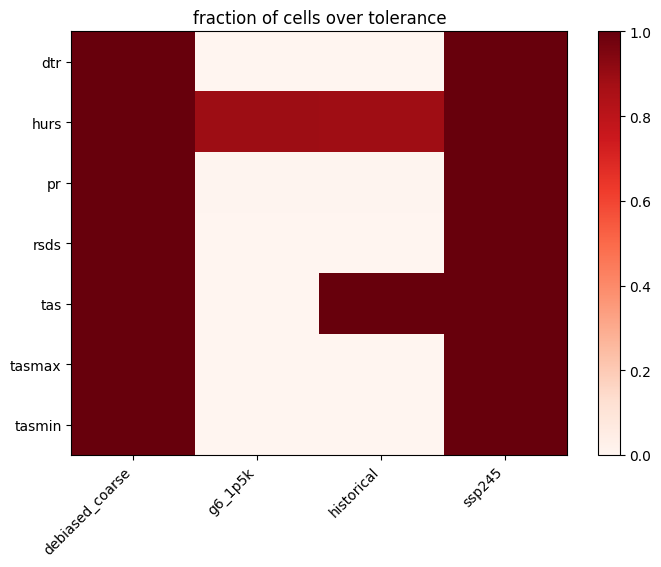

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

rows = sorted({lf.variable for lf in report.leaves})
cols = sorted({lf.path.split("/")[0] for lf in report.leaves})
grid = pd.DataFrame(float("nan"), index=rows, columns=cols)
for lf in report.leaves:
    grid.loc[lf.variable, lf.path.split("/")[0]] = lf.frac_over_tol
fig, ax = plt.subplots(figsize=(1.5 * len(cols) + 2, 0.5 * len(rows) + 2))
im = ax.imshow(grid.values, aspect="auto", cmap="Reds")
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticks(range(len(rows)))
ax.set_yticklabels(rows)
ax.set_title("fraction of cells over tolerance")
fig.colorbar(im, ax=ax)
plt.show()

In [4]:
from srm.config import SCENARIO_TO_GROUP

# The report above covers all leaves (including debiased_coarse); the plots below focus
# on the final products for readability. candidate_tree and snapshot_tree (already
# subset for the southafrica mode) come from the compare cell.
KNOWN_GROUPS = set(SCENARIO_TO_GROUP.values())
scen_list = scenarios or sorted(
    KNOWN_GROUPS & set(snapshot_tree.children) & set(candidate_tree.children)
)


def leaf_da(tree, scenario, variable):
    """Return the member-level DataArray for one (scenario, variable) leaf.

    The member is discovered as the single child node, so no member ID is hardcoded.
    """
    node = tree[f"{scenario}/{variable}"]
    member = next(iter(node.children))
    return node[member].to_dataset(inherit=False)[variable]

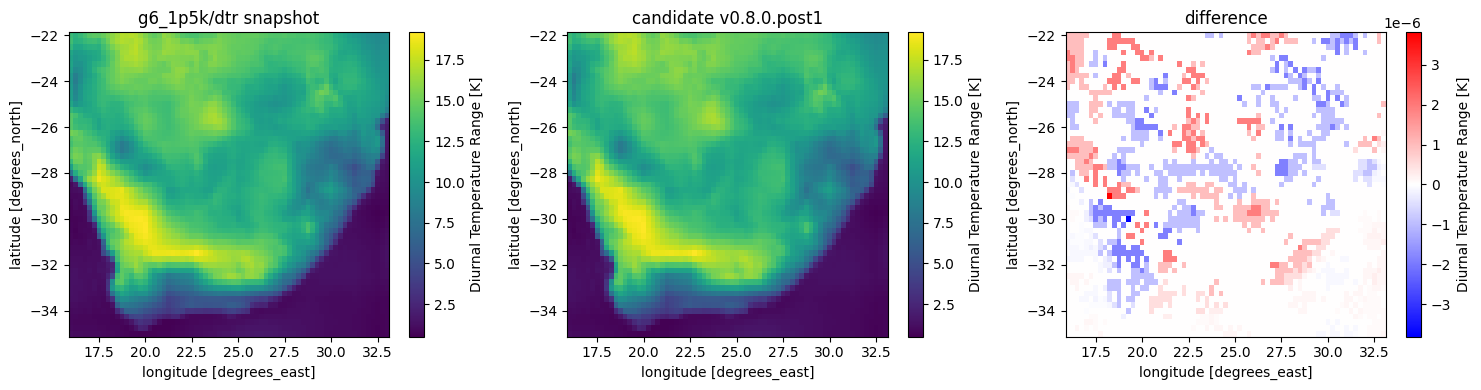

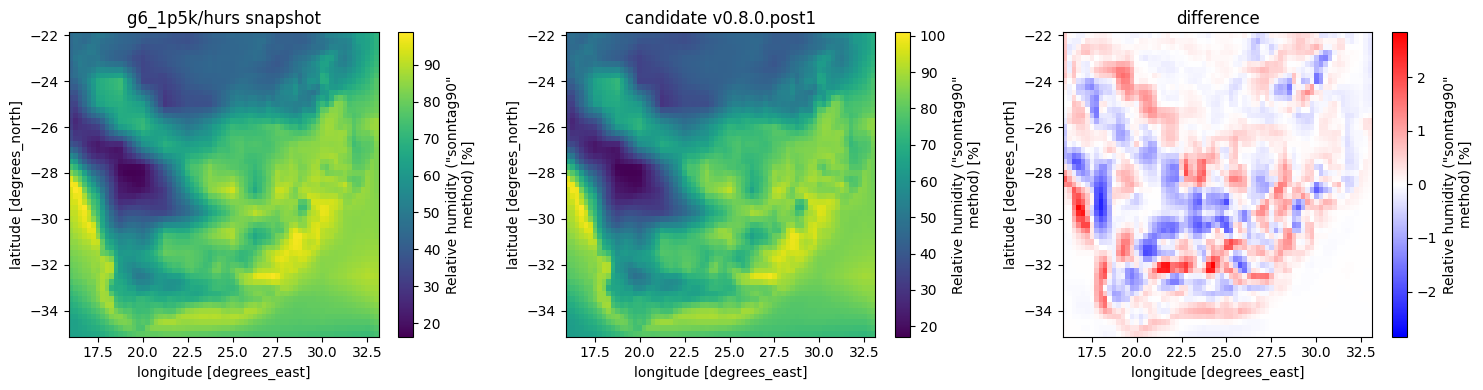

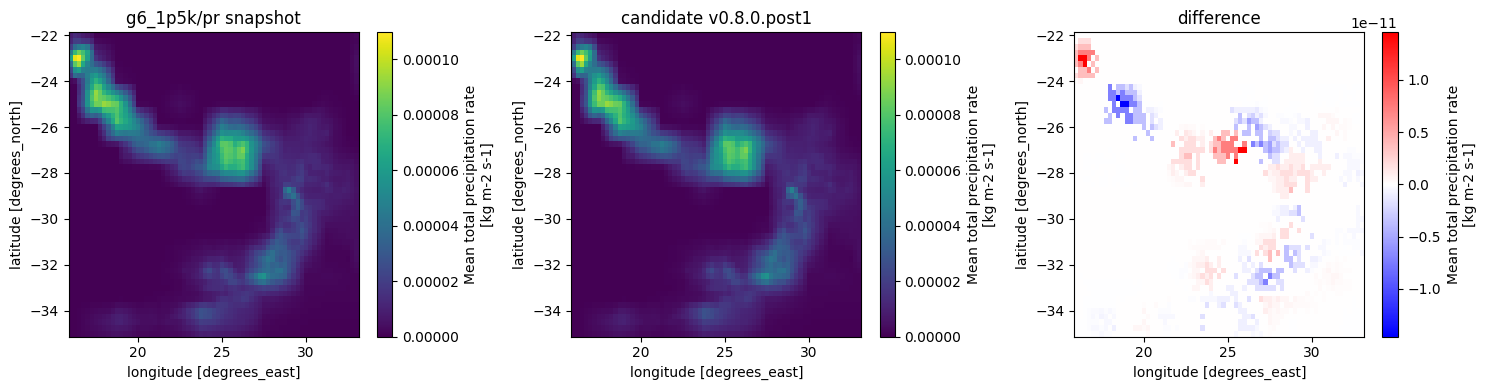

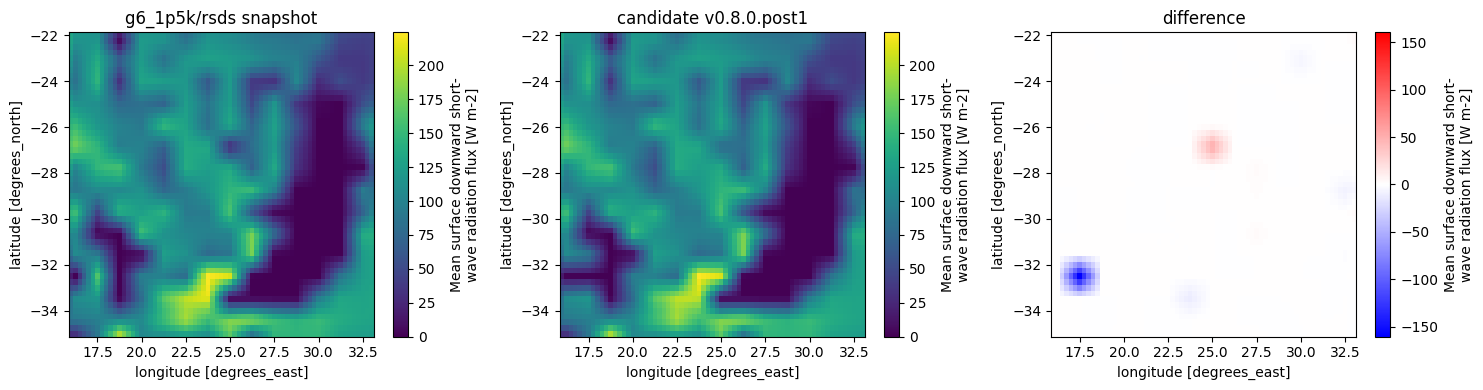

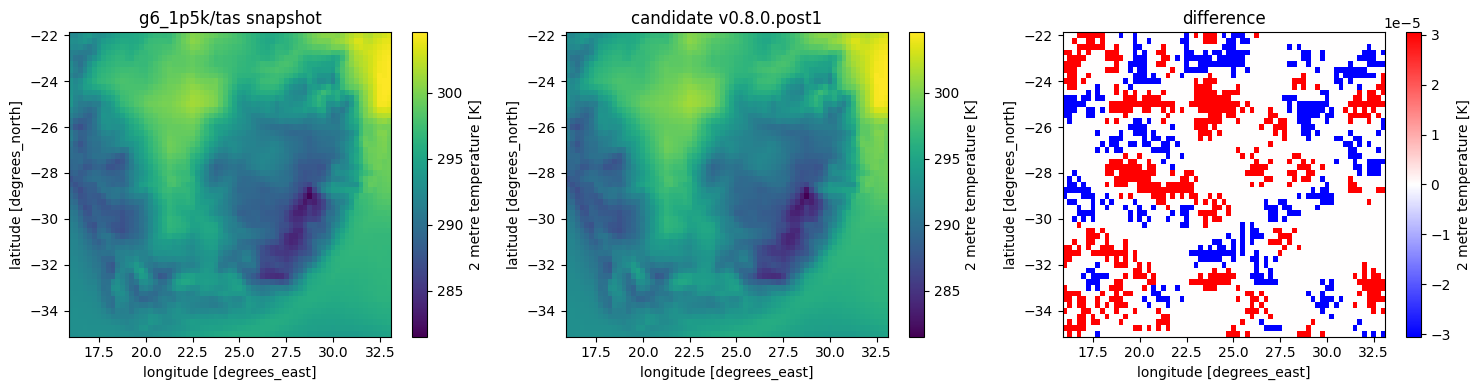

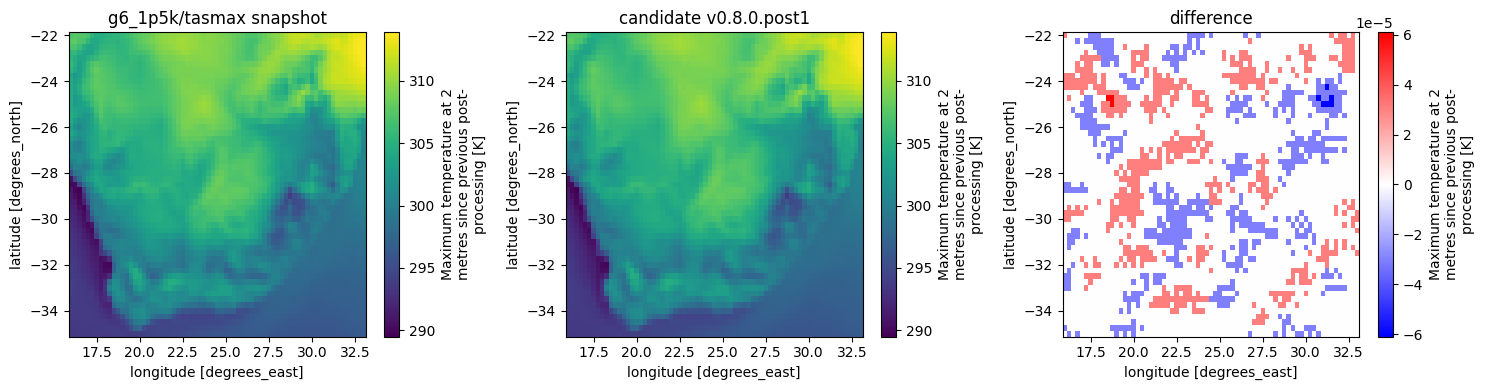

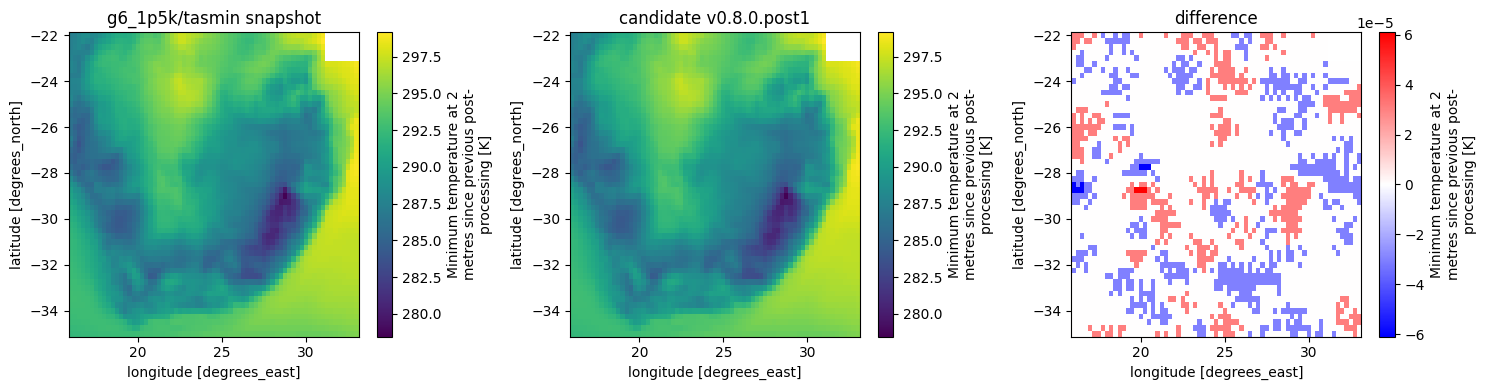

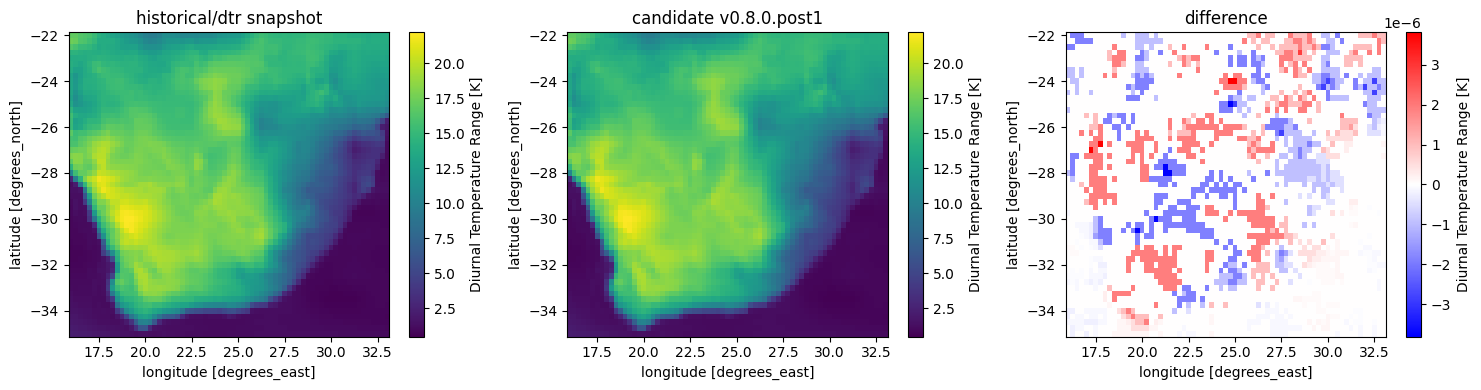

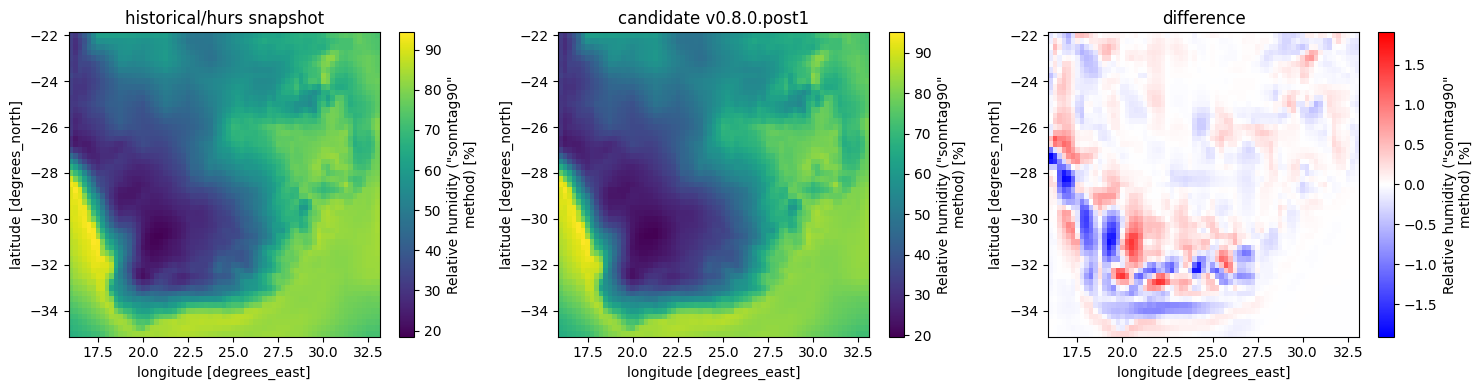

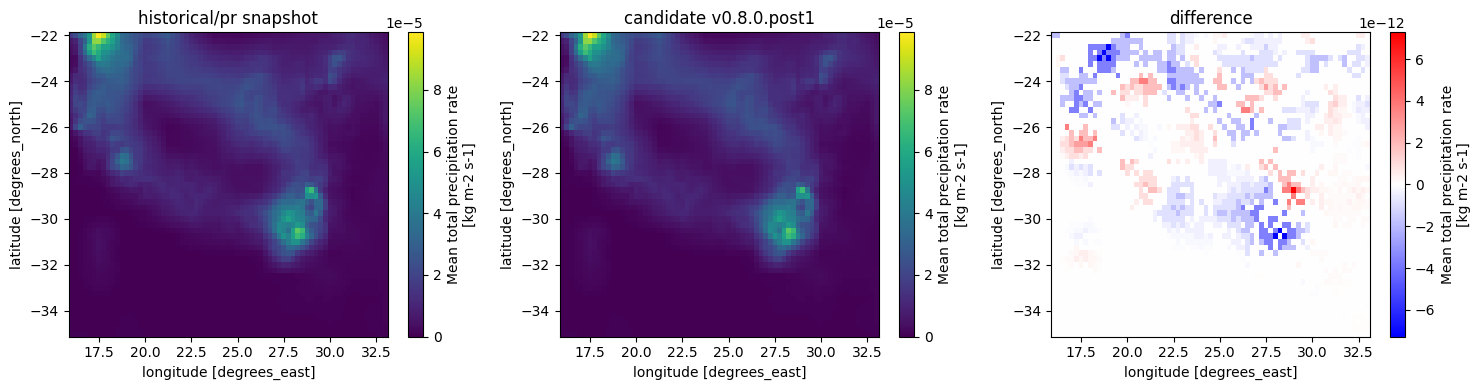

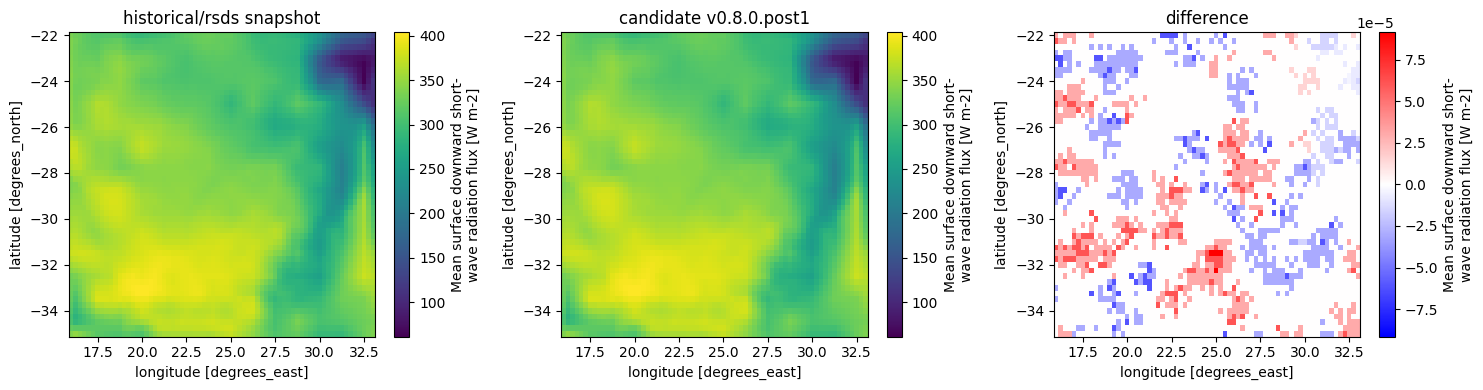

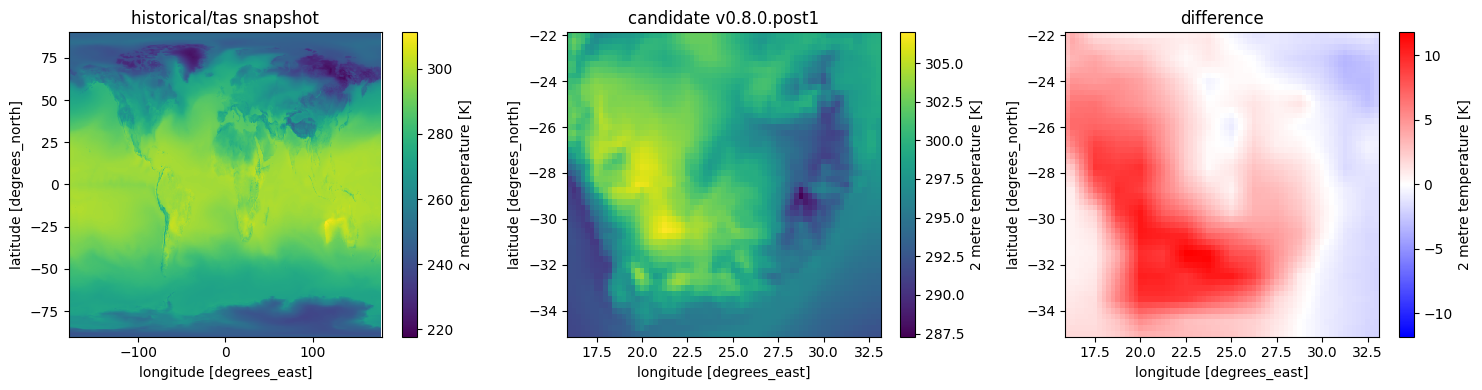

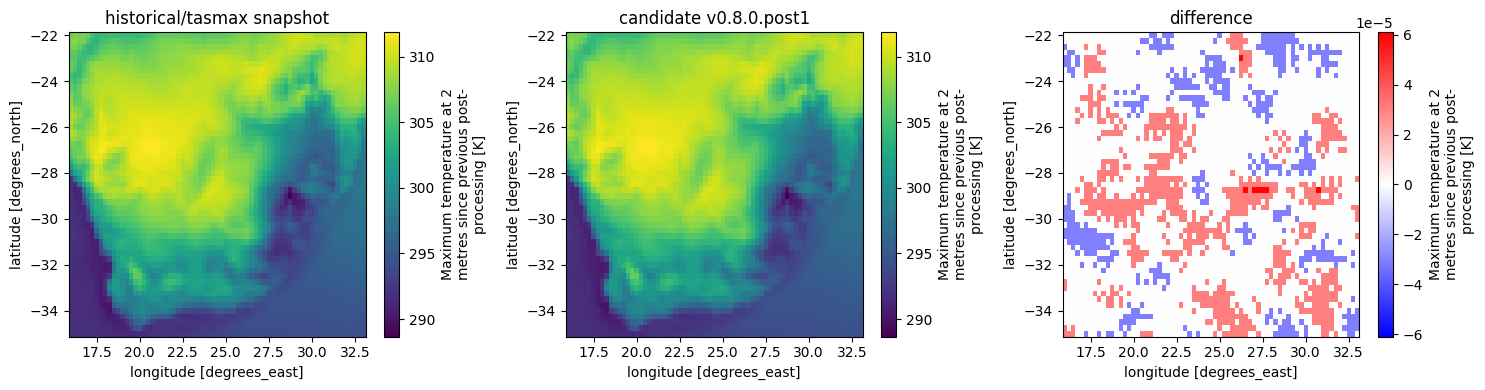

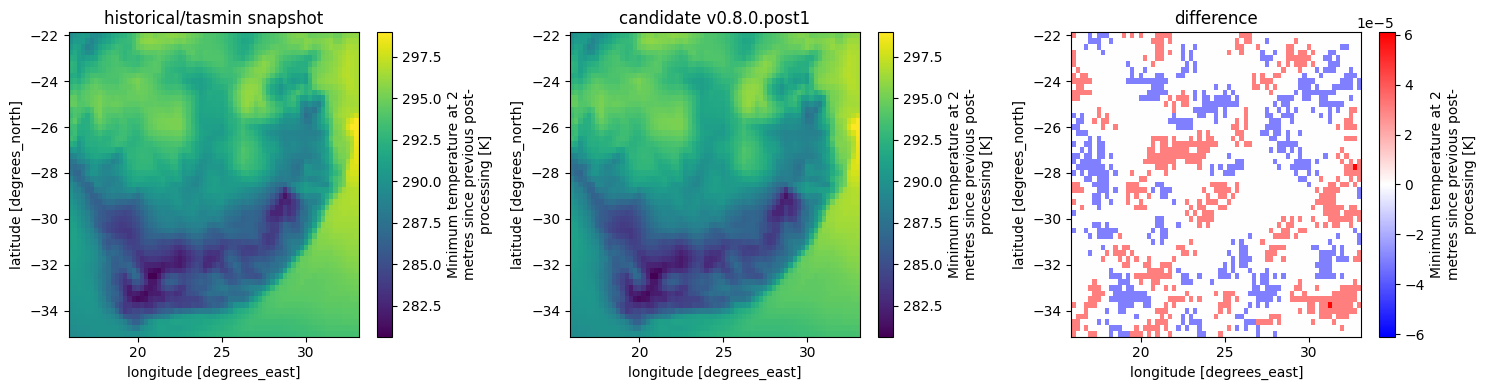

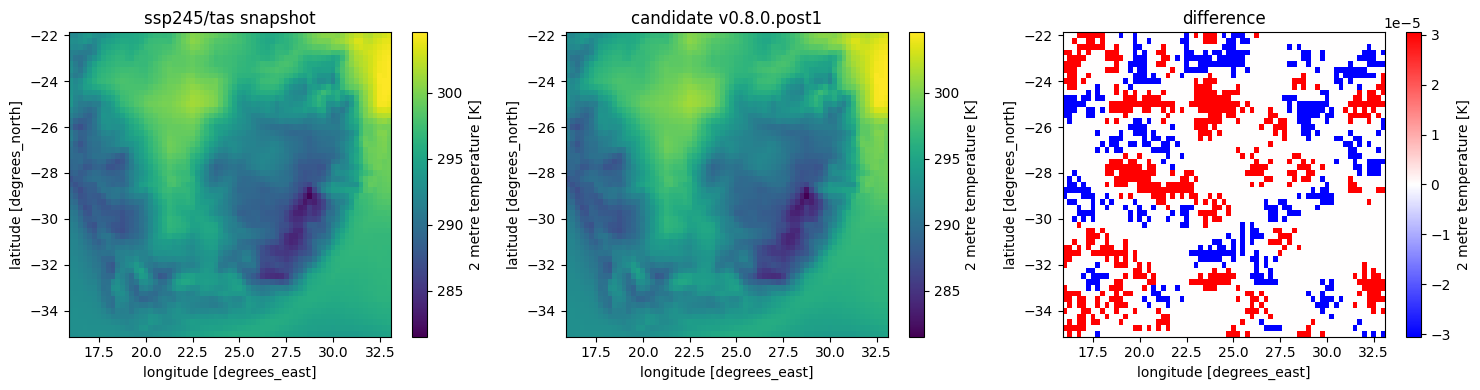

In [5]:
# Difference maps: snapshot vs candidate vs (candidate - snapshot) at one time step.
for scenario in scen_list:
    snap_vars = set(snapshot_tree[scenario].children)
    cand_vars = set(candidate_tree[scenario].children)
    for variable in sorted(snap_vars & cand_vars):
        if variables and variable not in variables:
            continue
        s0 = leaf_da(snapshot_tree, scenario, variable).isel(time=time_index)
        c0 = leaf_da(candidate_tree, scenario, variable).isel(time=time_index)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        s0.plot(ax=axes[0])
        axes[0].set_title(f"{scenario}/{variable} snapshot")
        c0.plot(ax=axes[1])
        axes[1].set_title(f"candidate {candidate_branch}")
        (c0 - s0).plot(ax=axes[2], cmap="bwr", center=0)
        axes[2].set_title("difference")
        plt.tight_layout()
        plt.show()

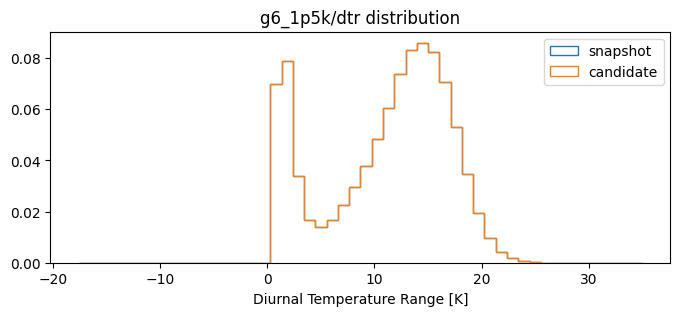

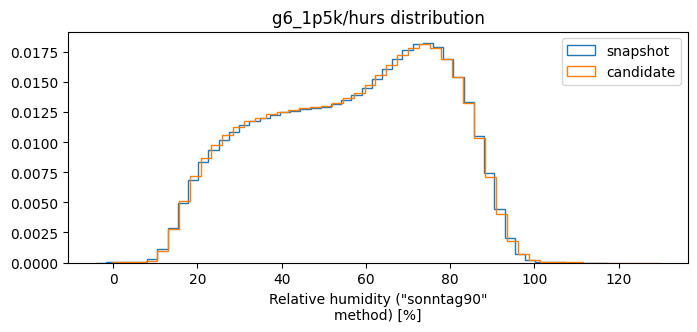

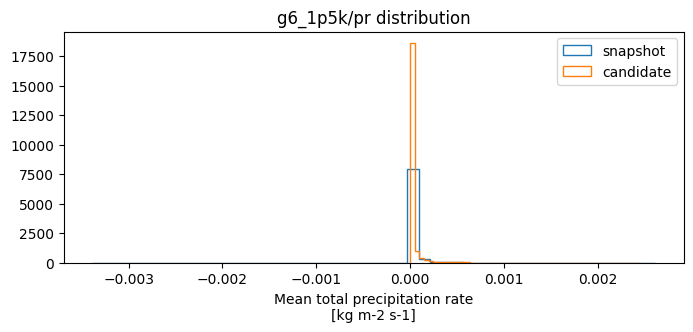

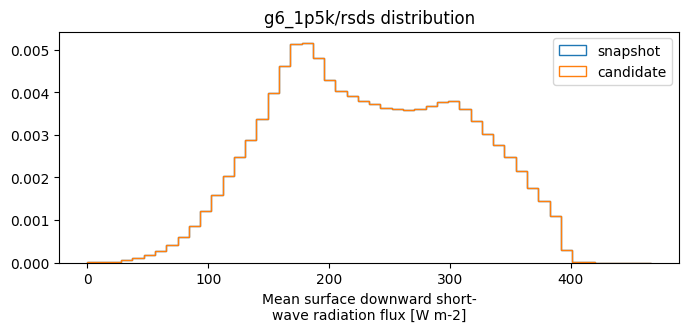

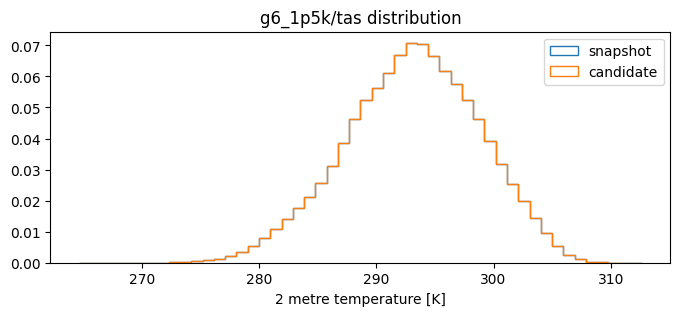

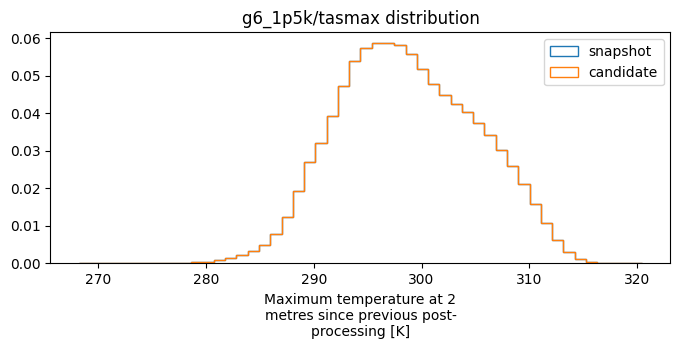

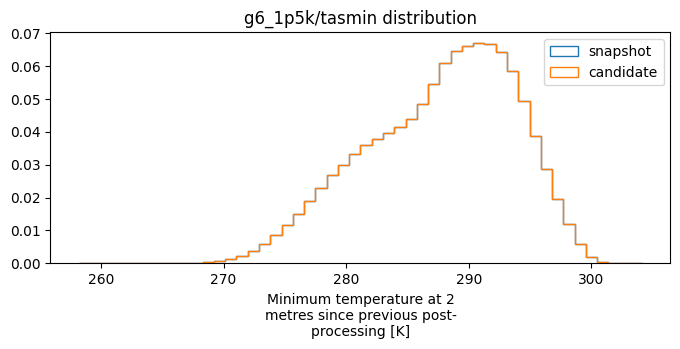

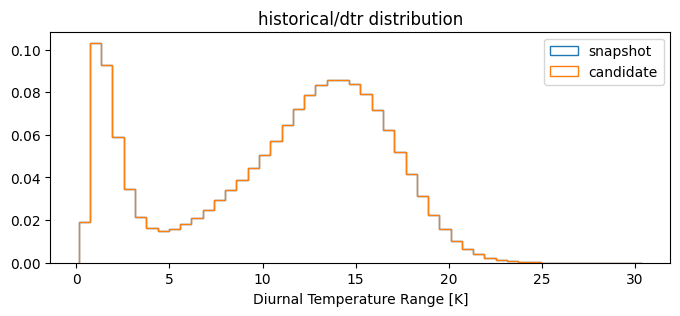

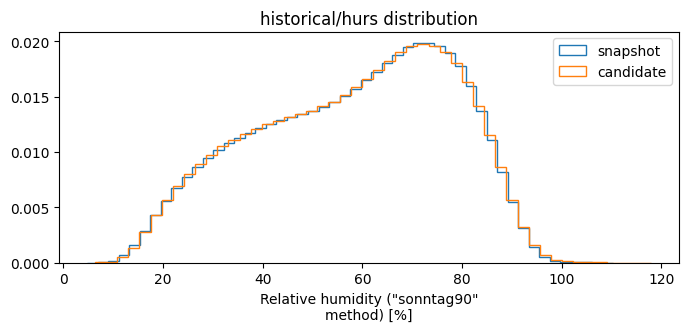

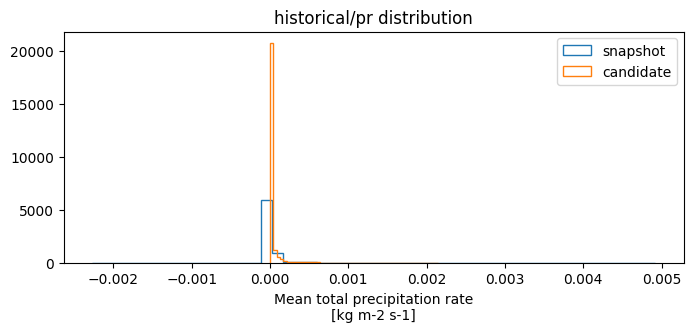

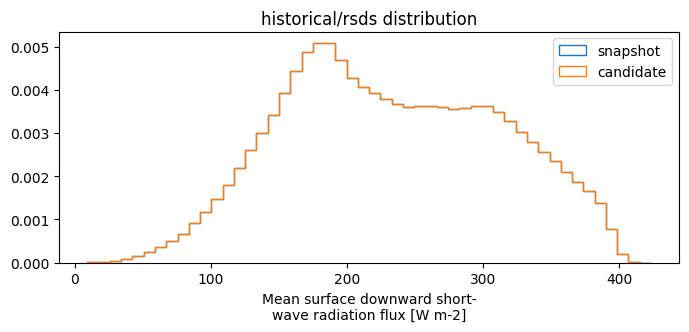

In [ ]:
# Value distributions: snapshot vs candidate, per scenario/variable.
for scenario in scen_list:
    snap_vars = set(snapshot_tree[scenario].children)
    cand_vars = set(candidate_tree[scenario].children)
    for variable in sorted(snap_vars & cand_vars):
        if variables and variable not in variables:
            continue
        s = leaf_da(snapshot_tree, scenario, variable)
        c = leaf_da(candidate_tree, scenario, variable)
        fig, ax = plt.subplots(figsize=(8, 3))
        s.plot.hist(bins=50, histtype="step", density=True, ax=ax, label="snapshot")
        c.plot.hist(bins=50, histtype="step", density=True, ax=ax, label="candidate")
        ax.set_title(f"{scenario}/{variable} distribution")
        ax.legend()
        plt.show()

In [ ]:
print(
    "OVERALL:",
    "PASS (no change beyond tolerance)" if report.within_tolerance else "FAIL (changes detected)",
)
for leaf in sorted(report.leaves, key=lambda lf: lf.path):
    if not leaf.within_tol:
        print(
            f"  changed: {leaf.path}  max_abs={leaf.max_abs_diff:.3e}  "
            f"frac>tol={leaf.frac_over_tol:.3e}"
        )